In [22]:
import numpy as np
import pandas as pd
from models.sbts_multi import simulateSB_multi
from models.sbts_multi_markov import simulateSB_multi_mark
from metrics.eval_functions import get_stats

In [6]:
# ========== LOAD & PREPARE ==========
data = pd.read_csv("data/sp500_top10_prices.csv")
numeric_cols = data.select_dtypes(include=[np.number]).columns
data = data[numeric_cols].ffill().bfill()

log_returns = np.log(data / data.shift(1)).dropna().values

window_size = 10
d = log_returns.shape[1]

# ========== CREATE WINDOWS ==========
X_all = np.array([log_returns[i:i+window_size] for i in range(len(log_returns) - window_size)])
N_windows = X_all.shape[0]
N = window_size

X = np.zeros((N_windows, window_size+1, d))
X[:, 1:, :] = X_all

print(f"Data shape: {X.shape}")
print(f"Window size: {window_size}\n")

Data shape: (3258, 11, 9)
Window size: 10



In [15]:
import numpy as np
import pandas as pd

# Load
data = pd.read_csv("data/sp500_top10_prices.csv")
numeric_cols = data.select_dtypes(include=[np.number]).columns
data = data[numeric_cols].ffill().bfill()

log_returns = np.log(data / data.shift(1)).dropna().values

# Calculer autocorrélation pour chaque asset
print("Autocorrelation (lag=1) for each asset:\n")

for i, col in enumerate(data.columns):
    # ACF simple: corr(t, t-1)
    acf_val = np.corrcoef(log_returns[:-1, i], log_returns[1:, i])[0, 1]
    print(f"{col}: ACF(1) = {acf_val:.6f}")

print("\nInterpretation:")
print("ACF < 0.05:   ✗ Pas d'autocorrélation → K=0 meilleur")
print("ACF 0.05-0.2: ⚠️ Faible autocorrélation → K=0 ou K=1?")
print("ACF > 0.2:    ✓ Forte autocorrélation → K=1+ recommandé")

Autocorrelation (lag=1) for each asset:

AAPL: ACF(1) = -0.040060
MSFT: ACF(1) = -0.019710
NVDA: ACF(1) = -0.105793
TSLA: ACF(1) = -0.042265
AMZN: ACF(1) = -0.075124
GOOGL: ACF(1) = -0.032152
META: ACF(1) = -0.113857
BRK-B: ACF(1) = -0.072007
JNJ: ACF(1) = -0.007853

Interpretation:
ACF < 0.05:   ✗ Pas d'autocorrélation → K=0 meilleur
ACF 0.05-0.2: ⚠️ Faible autocorrélation → K=0 ou K=1?
ACF > 0.2:    ✓ Forte autocorrélation → K=1+ recommandé


y'a une mean reversion logiquement un AR1 serait pas mal

In [24]:
from models.flow_matching import ImprovedFlowMatchingOT
from metrics.eval_functions import get_stats, get_scores, plot_sample_multi
import pandas as pd
import numpy as np
import torch
import sys
from pathlib import Path

def main():
    print("="*70)
    print("FLOW MATCHING FOR FINANCIAL TIME SERIES (IMPROVED)")
    print("="*70 + "\n")
    
    # Load data
    print("Loading data...")
    data = pd.read_csv("data/sp500_top10_prices.csv")
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    data = data[numeric_cols].ffill().bfill()
    asset_names = numeric_cols.tolist()
    
    log_returns = np.log(data / data.shift(1)).dropna().values
    
    window_size = 10
    X_all = np.array([
        log_returns[i:i+window_size] 
        for i in range(len(log_returns) - window_size)
    ])
    
    print(f"✓ Data: {X_all.shape}\n")
    
    # Create IMPROVED model
    fm = ImprovedFlowMatchingOT(
        window_size=window_size,
        n_assets=X_all.shape[2],
        sigma_min=0.8,
        hidden_dim=512  # Augmenté
    )
    
    # Train with more epochs
    print("Training (150 epochs)...")
    losses = fm.train(X_all, epochs=150, batch_size=32)
    print()
    
    # Generate
    X_synth = fm.generate(n_samples=1000, n_steps=100)
    
    # Save
    print("Saving...")
    np.save('X_synth_fm_returns_improved.npy', X_synth)
    X_synth_prices = np.exp(X_synth.cumsum(axis=1)) * 100
    np.save('X_synth_fm_prices_improved.npy', X_synth_prices)
    print("✓ Saved: X_synth_fm_returns_improved.npy, X_synth_fm_prices_improved.npy\n")
    
    # ========== STATISTICAL EVALUATION ==========
    print("="*70)
    print("STATISTICAL EVALUATION")
    print("="*70 + "\n")
    
    stats = get_stats(X_all, X_synth, col=asset_names)
    print("Statistics (Real vs Flow Matching):")
    print(stats)
    print()
    
    # ========== DISCRIMINATIVE & PREDICTIVE SCORES ==========
    print("="*70)
    print("DISCRIMINATIVE & PREDICTIVE SCORES")
    print("="*70 + "\n")
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    try:
        print("Computing scores (this may take several minutes)...\n")
        disc_scores, pred_scores = get_scores(
            X_all,
            X_synth,
            col_pred=None,
            itt=1000,
            n_temp=5,
            min_max=False,
            device=device
        )
        
        print("\n" + "="*70)
        print("RESULTS")
        print("="*70)
        print(f"\nDiscriminative Score (lower = better):")
        print(f"  Mean ± Std: {disc_scores.mean():.4f} ± {disc_scores.std():.4f}")
        
        print(f"\nPredictive Score (lower = better):")
        print(f"  Mean ± Std: {pred_scores.mean():.4f} ± {pred_scores.std():.4f}")
        print()
        
    except Exception as e:
        print(f"⚠️  Scores computation skipped: {e}\n")
    
    # ========== VISUALIZATION ==========
    print("="*70)
    print("VISUALIZATION")
    print("="*70 + "\n")
    
    try:
        plot_sample_multi(X_all, X_synth, col=asset_names, x0=0)
        print("✓ Plot displayed\n")
    except Exception as e:
        print(f"⚠️  Visualization skipped: {e}\n")
    
    print("="*70)
    print("✓ DONE!")
    print("="*70)
 
 
if __name__ == "__main__":
    main()
 

FLOW MATCHING FOR FINANCIAL TIME SERIES (IMPROVED)

Loading data...
✓ Data: (3258, 10, 9)



TypeError: ImprovedFlowMatchingOT.__init__() got an unexpected keyword argument 'sigma_min'

Loading data...
✓ Real data: (3258, 10, 9)

Loading synthetic data...
✓ SBTS (K=0): (2000, 10, 9)
✓ Flow Matching: (1000, 10, 9)

STATISTICAL COMPARISON: SBTS vs FLOW MATCHING

SBTS STATISTICS:
         1% Data  1% SBTS  99% Data  99% SBTS  Mean Data  Mean SBTS  Std Data  \
Feature                                                                         
AAPL      -0.049   -0.048     0.047     0.043      0.001     -0.001     0.018   
MSFT      -0.058   -0.056     0.056     0.049      0.001      0.002     0.020   
NVDA      -0.030   -0.041     0.031     0.041      0.001      0.000     0.012   
TSLA      -0.048   -0.041     0.048     0.043      0.001      0.001     0.018   
AMZN      -0.029   -0.038     0.028     0.040      0.000      0.001     0.011   
GOOGL     -0.060   -0.049     0.060     0.049      0.001      0.002     0.024   
META      -0.043   -0.049     0.045     0.046      0.001      0.001     0.017   
BRK-B     -0.075   -0.060     0.073     0.060      0.002      0.003     0.029

/Users/taniaadmane/Desktop/S2 ENSAE/optimal transport/Optimal-Transport/metrics/predictive_score.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ori_data = torch.tensor(ori_data, dtype=torch.float32).to(device)
/Users/taniaadmane/Desktop/S2 ENSAE/optimal transport/Optimal-Transport/metrics/predictive_score.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  generated_data = torch.tensor(generated_data, dtype=torch.float32).to(device)


Expected finish time: 13:10:33


/Users/taniaadmane/Desktop/S2 ENSAE/optimal transport/Optimal-Transport/metrics/predictive_score.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ori_data = torch.tensor(ori_data, dtype=torch.float32).to(device)
/Users/taniaadmane/Desktop/S2 ENSAE/optimal transport/Optimal-Transport/metrics/predictive_score.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  generated_data = torch.tensor(generated_data, dtype=torch.float32).to(device)
/Users/taniaadmane/Desktop/S2 ENSAE/optimal transport/Optimal-Transport/metrics/predictive_score.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_

Discriminative score (lower the better): 0.226 +- 0.014
Predictive score (lower the better): 0.026 +- 0.0

✓ SBTS Results:
  Discriminative: 0.2258 ± 0.0143
  Predictive:     0.0257 ± 0.0001


Computing Flow Matching scores...
Start time: 13:10:39


/Users/taniaadmane/Desktop/S2 ENSAE/optimal transport/Optimal-Transport/metrics/predictive_score.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ori_data = torch.tensor(ori_data, dtype=torch.float32).to(device)
/Users/taniaadmane/Desktop/S2 ENSAE/optimal transport/Optimal-Transport/metrics/predictive_score.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  generated_data = torch.tensor(generated_data, dtype=torch.float32).to(device)


Expected finish time: 13:11:07


/Users/taniaadmane/Desktop/S2 ENSAE/optimal transport/Optimal-Transport/metrics/predictive_score.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ori_data = torch.tensor(ori_data, dtype=torch.float32).to(device)
/Users/taniaadmane/Desktop/S2 ENSAE/optimal transport/Optimal-Transport/metrics/predictive_score.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  generated_data = torch.tensor(generated_data, dtype=torch.float32).to(device)
/Users/taniaadmane/Desktop/S2 ENSAE/optimal transport/Optimal-Transport/metrics/predictive_score.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_

Discriminative score (lower the better): 0.496 +- 0.007
Predictive score (lower the better): 0.029 +- 0.002

✓ Flow Matching Results:
  Discriminative: 0.4955 ± 0.0066
  Predictive:     0.0290 ± 0.0017

VISUALIZATION

Plotting REAL DATA vs SBTS...
✓ Saved: sbts_sample.png

Plotting REAL DATA vs FLOW MATCHING...
✓ Saved: fm_sample.png

FINAL COMPARISON TABLE


SBTS DETAILED STATISTICS
         1% Data  1% SBTS  99% Data  99% SBTS  Mean Data  Mean SBTS  Std Data  \
Feature                                                                         
AAPL      -0.049   -0.048     0.047     0.043      0.001     -0.001     0.018   
MSFT      -0.058   -0.056     0.056     0.049      0.001      0.002     0.020   
NVDA      -0.030   -0.041     0.031     0.041      0.001      0.000     0.012   
TSLA      -0.048   -0.041     0.048     0.043      0.001      0.001     0.018   
AMZN      -0.029   -0.038     0.028     0.040      0.000      0.001     0.011   
GOOGL     -0.060   -0.049     0.060     0.049 

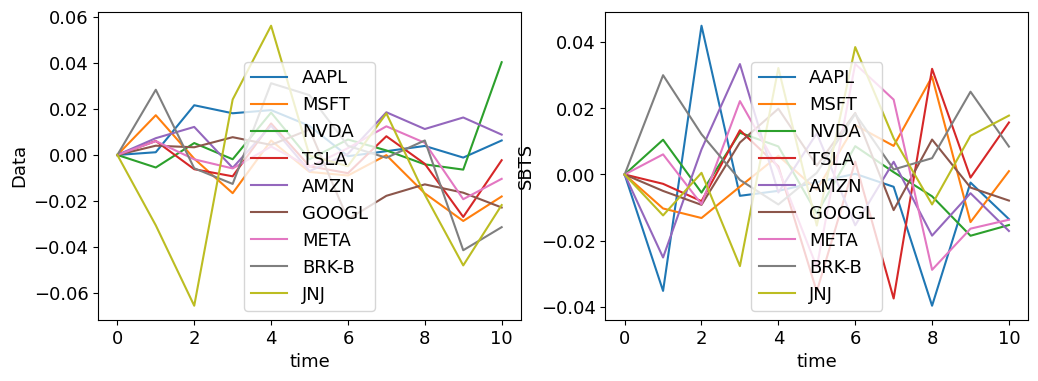

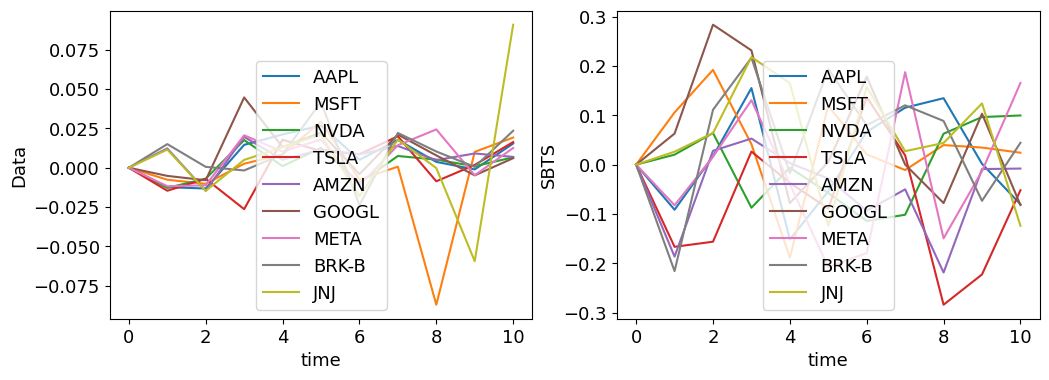

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
from metrics.eval_functions import get_stats, plot_sample_multi

# ========== LOAD DATA ==========
print("Loading data...")
data = pd.read_csv("data/sp500_top10_prices.csv")
numeric_cols = data.select_dtypes(include=[np.number]).columns
data = data[numeric_cols].ffill().bfill()
asset_names = numeric_cols.tolist()

log_returns = np.log(data / data.shift(1)).dropna().values

window_size = 10
X_real = np.array([
    log_returns[i:i+window_size] 
    for i in range(len(log_returns) - window_size)
])

print(f"✓ Real data: {X_real.shape}\n")

# ========== LOAD SYNTHETICS ==========
print("Loading synthetic data...")

# SBTS
X_sbts = np.load('X_synth_returns.npy')
print(f"✓ SBTS (K=0): {X_sbts.shape}")

# Flow Matching
try:
    X_fm = np.load('X_synth_fm_returns_improved.npy')
    print(f"✓ Flow Matching: {X_fm.shape}\n")
    has_fm = True
except:
    print("⚠️  Flow Matching file not found\n")
    has_fm = False

# ========== STATISTICAL EVALUATION ==========
print("="*70)
print("STATISTICAL COMPARISON: SBTS vs FLOW MATCHING")
print("="*70 + "\n")

print("SBTS STATISTICS:")
stats_sbts = get_stats(X_real, X_sbts, col=asset_names)
print(stats_sbts)
print()

if has_fm:
    print("\nFLOW MATCHING STATISTICS:")
    stats_fm = get_stats(X_real, X_fm, col=asset_names)
    print(stats_fm)
    print()

# ========== DISCRIMINATIVE & PREDICTIVE SCORES ==========
print("="*70)
print("DISCRIMINATIVE & PREDICTIVE SCORES")
print("="*70 + "\n")

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Computing SBTS scores...")
try:
    disc_scores_sbts, pred_scores_sbts = get_scores(
        X_real,
        X_sbts,
        col_pred=None,
        itt=1000,
        n_temp=5,
        min_max=False,
        device=device
    )
    print(f"\n✓ SBTS Results:")
    print(f"  Discriminative: {disc_scores_sbts.mean():.4f} ± {disc_scores_sbts.std():.4f}")
    print(f"  Predictive:     {pred_scores_sbts.mean():.4f} ± {pred_scores_sbts.std():.4f}\n")
except Exception as e:
    print(f"⚠️  SBTS scores failed: {e}\n")
    disc_scores_sbts = None

if has_fm:
    print("\nComputing Flow Matching scores...")
    try:
        disc_scores_fm, pred_scores_fm = get_scores(
            X_real,
            X_fm,
            col_pred=None,
            itt=1000,
            n_temp=5,
            min_max=False,
            device=device
        )
        print(f"\n✓ Flow Matching Results:")
        print(f"  Discriminative: {disc_scores_fm.mean():.4f} ± {disc_scores_fm.std():.4f}")
        print(f"  Predictive:     {pred_scores_fm.mean():.4f} ± {pred_scores_fm.std():.4f}\n")
    except Exception as e:
        print(f"⚠️  FM scores failed: {e}\n")
        disc_scores_fm = None

# ========== VISUALIZATION ==========
print("="*70)
print("VISUALIZATION")
print("="*70 + "\n")

print("Plotting REAL DATA vs SBTS...")
plot_sample_multi(X_real, X_sbts, col=asset_names, x0=0)
plt.savefig('sbts_sample.png', dpi=150, bbox_inches='tight')
print("✓ Saved: sbts_sample.png\n")

if has_fm:
    print("Plotting REAL DATA vs FLOW MATCHING...")
    plot_sample_multi(X_real, X_fm, col=asset_names, x0=0)
    plt.savefig('fm_sample.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: fm_sample.png\n")

# ========== DETAILED STATS TABLE ==========
print("="*70)
print("FINAL COMPARISON TABLE")
print("="*70 + "\n")

if disc_scores_sbts is not None:
    print("\n" + "="*70)
    print("SBTS DETAILED STATISTICS")
    print("="*70)
    print(stats_sbts)
    print()

if has_fm and disc_scores_fm is not None:
    print("\n" + "="*70)
    print("FLOW MATCHING DETAILED STATISTICS")
    print("="*70)
    print(stats_fm)
    print()

# ========== WINNER ==========
print("="*70)
print("SUMMARY")
print("="*70 + "\n")

if disc_scores_sbts is not None and has_fm and disc_scores_fm is not None:
    print("🥇 WINNER:")
    if disc_scores_sbts.mean() < disc_scores_fm.mean():
        print(f"   SBTS (Disc: {disc_scores_sbts.mean():.4f} vs FM: {disc_scores_fm.mean():.4f})")
    else:
        print(f"   FLOW MATCHING (Disc: {disc_scores_fm.mean():.4f} vs SBTS: {disc_scores_sbts.mean():.4f})")
elif disc_scores_sbts is not None:
    print(f"✓ SBTS Discriminative Score: {disc_scores_sbts.mean():.4f} ± {disc_scores_sbts.std():.4f}")
    print(f"✓ SBTS Predictive Score:     {pred_scores_sbts.mean():.4f} ± {pred_scores_sbts.std():.4f}")

print("\n" + "="*70)
print("✓ EVALUATION COMPLETE!")
print("="*70)